Saving outputs to: /content/drive/My Drive/Data Distribution
Plot saved successfully to: /content/drive/My Drive/Data Distribution/Coverage_Comparison_Single_Patch_vs_MIL_16700.png


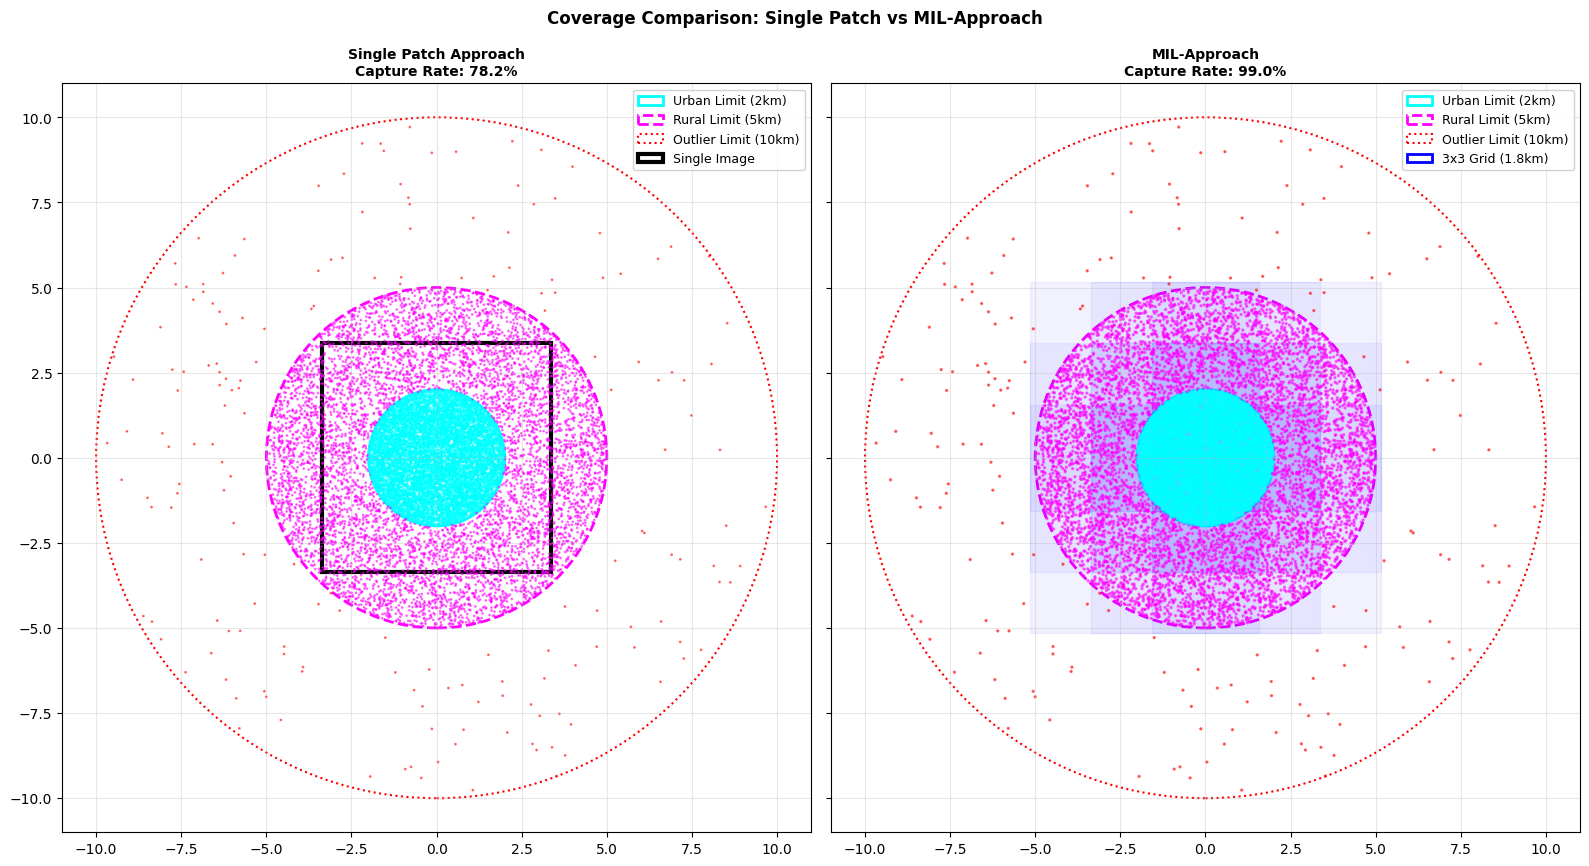

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from google.colab import drive

# ==========================================
# 0. SETUP DRIVE & SAVE PATH
# ==========================================
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

SAVE_DIR = "/content/drive/My Drive/Data Distribution"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving outputs to: {SAVE_DIR}")

# ==========================================
# 1. CONFIGURATION
# ==========================================
IMG_SIZE_KM = 6.72
MIL_SPACING = 1.8
NUM_SIMULATIONS = 16700  # Updated to 16,700 clusters

# Radii
URBAN_RADIUS = 2.0
RURAL_RADIUS = 5.0
OUTLIER_RADIUS = 10.0

# Distribution Probabilities (Sum to 1.0)
P_URBAN = 0.58
P_OUTLIER = 0.01      # 1% of TOTAL clusters are outliers
P_RURAL_STD = 0.41

def check_capture(village_x, village_y, box_centers_x, box_centers_y, box_size):
    half = box_size / 2.0
    for cx in box_centers_x:
        for cy in box_centers_y:
            if (cx - half <= village_x <= cx + half) and \
               (cy - half <= village_y <= cy + half):
                return True
    return False

# ==========================================
# 2. RUN SIMULATION
# ==========================================
yeh_hits = 0
mil_hits = 0
points_x, points_y, colors = [], [], []

for _ in range(NUM_SIMULATIONS):
    rand_val = np.random.random()

    if rand_val < P_URBAN:
        # Urban (0-2km)
        min_r, max_r, c = 0.0, URBAN_RADIUS, 'cyan'
    elif rand_val < (P_URBAN + P_RURAL_STD):
        # Standard Rural (2-5km)
        min_r, max_r, c = URBAN_RADIUS, RURAL_RADIUS, 'magenta'
    else:
        # Outlier (5-10km) - Exact 1% of total
        min_r, max_r, c = RURAL_RADIUS, OUTLIER_RADIUS, 'red'

    # Uniform Area Sampling (sqrt of random)
    r_squared = np.random.uniform(min_r**2, max_r**2)
    distance = np.sqrt(r_squared)
    angle = np.random.uniform(0, 2 * np.pi)

    vx = distance * np.cos(angle)
    vy = distance * np.sin(angle)

    points_x.append(vx)
    points_y.append(vy)
    colors.append(c)

    # Method A: Yeh et al.
    if check_capture(vx, vy, [0], [0], IMG_SIZE_KM):
        yeh_hits += 1

    # Method B: MIL
    offsets = [-MIL_SPACING, 0, MIL_SPACING]
    if check_capture(vx, vy, offsets, offsets, IMG_SIZE_KM):
        mil_hits += 1

# ==========================================
# 3. PLOT & SAVE
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

def add_rings(axis):
    axis.add_patch(plt.Circle((0, 0), URBAN_RADIUS, color='cyan', fill=False, ls='-', lw=2, label='Urban Limit (2km)'))
    axis.add_patch(plt.Circle((0, 0), RURAL_RADIUS, color='magenta', fill=False, ls='--', lw=2, label='Rural Limit (5km)'))
    axis.add_patch(plt.Circle((0, 0), OUTLIER_RADIUS, color='red', fill=False, ls=':', lw=1.5, label='Outlier Limit (10km)'))

# --- PLOT 1: Single Patch ---
yeh_rate = yeh_hits / NUM_SIMULATIONS
ax[0].set_title(f"Single Patch Approach\nCapture Rate: {yeh_rate:.1%}", fontsize=10, weight = "bold")
ax[0].set_xlim(-11, 11); ax[0].set_ylim(-11, 11)
ax[0].set_aspect('equal')
add_rings(ax[0])
ax[0].add_patch(patches.Rectangle((-IMG_SIZE_KM/2, -IMG_SIZE_KM/2), IMG_SIZE_KM, IMG_SIZE_KM,
                                  linewidth=3, edgecolor='black', facecolor='none', label='Single Image'))
# REDUCED POINT SIZE (s=2)
ax[0].scatter(points_x, points_y, c=colors, s=1, alpha=0.5)
ax[0].legend(loc='upper right', framealpha=0.9, fontsize=9)
ax[0].grid(True, alpha=0.3)

# --- PLOT 2: MIL ---
mil_rate = mil_hits / NUM_SIMULATIONS
ax[1].set_title(f"MIL-Approach\nCapture Rate: {mil_rate:.1%}", fontsize=10, weight = "bold")
ax[1].set_xlim(-11, 11); ax[1].set_ylim(-11, 11)
ax[1].set_aspect('equal')
add_rings(ax[1])
offsets = [-MIL_SPACING, 0, MIL_SPACING]
for dx in offsets:
    for dy in offsets:
        ax[1].add_patch(patches.Rectangle((dx - IMG_SIZE_KM/2, dy - IMG_SIZE_KM/2), IMG_SIZE_KM, IMG_SIZE_KM,
                                          linewidth=1, edgecolor='blue', facecolor='blue', alpha=0.05))
ax[1].add_patch(patches.Rectangle((0,0),0,0, linewidth=2, edgecolor='blue', facecolor='none', label='3x3 Grid (1.8km)'))
# REDUCED POINT SIZE (s=2)
ax[1].scatter(points_x, points_y, c=colors, s=2, alpha=0.5)
ax[1].legend(loc='upper right', framealpha=0.9, fontsize=9)
ax[1].grid(True, alpha=0.3)

plt.suptitle("Coverage Comparison: Single Patch vs MIL-Approach", fontsize=12, weight = "bold" )
plt.tight_layout()

filename = "Coverage_Comparison_Single_Patch_vs_MIL_16700.png"
save_path = os.path.join(SAVE_DIR, filename)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to: {save_path}")

plt.show()